In [64]:
import numpy as np
import pandas as pd
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/base_dummies.dta")

# Filtrar personas que reportaron su condición de actividad
df = df[df['estado'].isin([1, 2, 3])]

# Guardar la base filtrada
df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/respondieron.dta", write_index=False)

In [65]:
import numpy as np
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/respondieron.dta")

# Paso 1: Reemplazar valores vacíos por NaN
df['ch14'] = df['ch14'].replace({'': np.nan})

# Paso 2: Convertir todos los valores a strings para manejarlos de forma uniforme
df['ch14'] = df['ch14'].astype(str).str.strip()

# Paso 3: Función para limpiar cada valor
def convertir_a_entero(valor):
    if valor in ['98', '99', '98.0', '99.0']:
        return int(float(valor))  # mantener 98 y 99 como enteros
    try:
        # Convertimos valores como '01', '2.0', etc., a enteros
        return int(float(valor))
    except:
        return 0  # Si no se puede convertir, ponemos NaN

# Paso 4: Aplicar la función a toda la columna
df['ch14'] = df['ch14'].apply(convertir_a_entero)

In [68]:
df['ch12'] = pd.to_numeric(df['ch12'], errors='coerce')
df['ch13'] = pd.to_numeric(df['ch13'], errors='coerce')

In [70]:
import numpy as np
import pandas as pd

def calcular_anos_educacion(row):
    nivel = row['ch12']
    finalizo = row['ch13']
    ultimo_aprobado = row['ch14']

    if nivel == 9 or ultimo_aprobado in [98, 99]:
        return np.nan
    
    # Si finalizó el nivel
    if finalizo == 1:
        return {
            1: 0,
            2: 7,
            3: 9,
            4: 12,   # asumimos primaria + secundaria
            5: 12,
            6: 15,   # terciario
            7: 17,   # universitario
            8: 20,   # posgrado
        }.get(nivel, np.nan)

    # Si no lo finalizó
    if finalizo == 2:
        # Años previos al nivel actual
        previos = {
            1: 0,
            2: 0,
            3: 0,
            4: 9,
            5: 9,
            6: 12,
            7: 15,
            8: 17
        }.get(nivel, 0)

        # Validar que el año aprobado esté en rango
        if 1 <= ultimo_aprobado <= 9:
            return previos + ultimo_aprobado
        else:
            return np.nan

    return np.nan

# Asumiendo que tus datos están en un DataFrame llamado df:
df['anos_educacion'] = df.apply(calcular_anos_educacion, axis=1)

df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/creamos_variable.dta", write_index=False)

/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1916775321.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anos_educacion'] = df.apply(calcular_anos_educacion, axis=1)


In [72]:
import pandas as pd
import numpy as np

# Cargar el archivo .dta (asumimos que se cargó como df)
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/creamos_variable.dta")

# Filtrar los datos para eliminar ceros y valores negativos
df = df[df['p47t'] > 0]  # Suponiendo que 'p47t' es la columna de ingreso

# Recorte de outliers por percentiles
def sin_outliers(df, columna):
    q_low = df[columna].quantile(0.01)
    q_high = df[columna].quantile(0.99)
    return df[(df[columna] >= q_low) & (df[columna] <= q_high)]

# Aplicar el recorte de outliers en el DataFrame completo
df = sin_outliers(df, 'p47t')

# Ajustar por inflación, solo para los datos de 2004 (ano4 == 2004)
ajuste_inflacion = 500  # Factor de ajuste por inflación, ajusta según sea necesario
df.loc[df['ano4'] == 2004, 'p47t'] = df.loc[df['ano4'] == 2004, 'p47t'] * ajuste_inflacion

# Verificar el DataFrame después de los cambios
print(df[['ano4', 'p47t']].head())
# Crear la variable Edad al cuadrado (EDAD_CUAD)
df['edad_cuad'] = df['ch06']**2

# Crear la variable Experiencia potencial (EXPERIENCIA_POT)
df['experiencia_pot'] = df['ch06'] - df['nivel_ed'] - 6

# Crear la variable Edad * Experiencia (EDAD_X_EXP)
df['edad_x_exp'] = df['ch06'] * df['experiencia_pot']

# Crear la variable Logaritmo del ingreso (LOG_ING)
df['log_ing'] = np.log(df['p47t'])

# Crear la variable Ingresos laborales (ingreso total - ingresos no laborales)
df['ingreso_sin_subsidio'] = df['p47t'] - (df['t_vi'])

# Mostrar las primeras filas del DataFrame para verificar
print(df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio']].head())


df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta", write_index=False)

     ano4      p47t
0  2004.0  140000.0
2  2004.0   25000.0
3  2004.0  200000.0
5  2004.0  350000.0
8  2004.0  175000.0
   edad_cuad  experiencia_pot  edad_x_exp    log_ing  ingreso_sin_subsidio
0     5476.0             66.0      4884.0  11.849398              139720.0
2     1156.0             26.0       884.0  10.126631               25000.0
3      196.0              5.0        70.0  12.206073              199600.0
5     1225.0             25.0       875.0  12.765688              350000.0
8      900.0             21.0       630.0  12.072541              175000.0


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1810086435.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['edad_cuad'] = df['ch06']**2
/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1810086435.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['experiencia_pot'] = df['ch06'] - df['nivel_ed'] - 6
/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1810086435.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

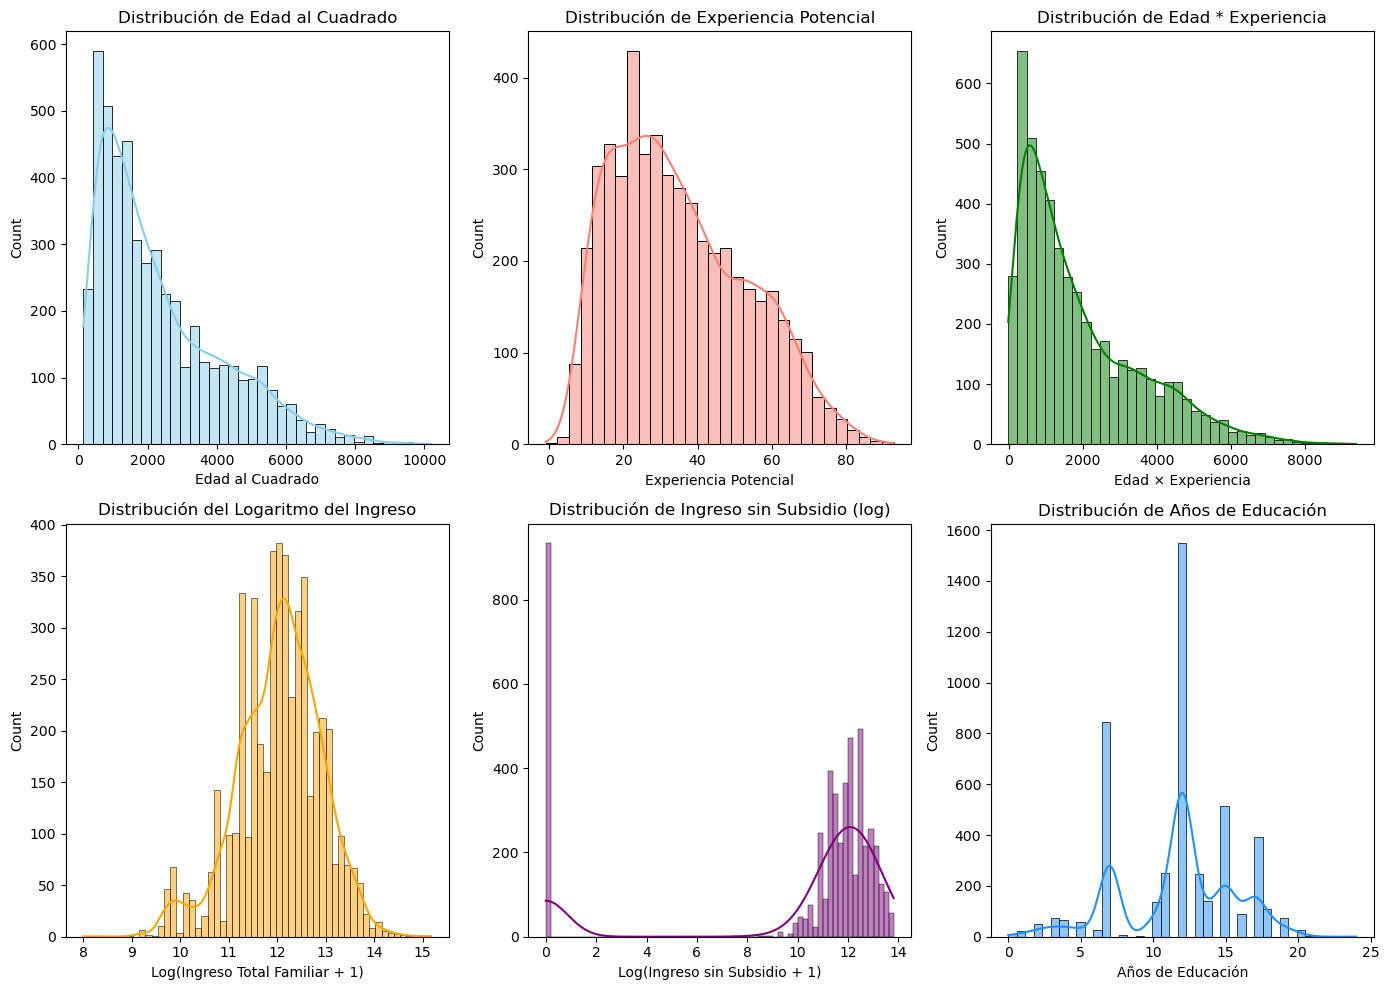

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Gráficos para variables continuas
plt.figure(figsize=(14, 10))

# 1. Edad al cuadrado
plt.subplot(2, 3, 1)
sns.histplot(df['edad_cuad'], kde=True, color='skyblue')
plt.title('Distribución de Edad al Cuadrado')
plt.xlabel('Edad al Cuadrado')

# 2. Experiencia potencial
plt.subplot(2, 3, 2)
sns.histplot(df['experiencia_pot'], kde=True, color='salmon')
plt.title('Distribución de Experiencia Potencial')
plt.xlabel('Experiencia Potencial')

# 3. Edad * Experiencia
plt.subplot(2, 3, 3)
sns.histplot(df['edad_x_exp'], kde=True, color='green')
plt.title('Distribución de Edad * Experiencia')
plt.xlabel('Edad × Experiencia')

# 4. Logaritmo del ingreso
plt.subplot(2, 3, 4)
sns.histplot(df['log_ing'], kde=True, color='orange')
plt.title('Distribución del Logaritmo del Ingreso')
plt.xlabel('Log(Ingreso Total Familiar + 1)')

# 5. Ingreso sin subsidio (log)
plt.subplot(2, 3, 5)
df_trimmed = df[df['ingreso_sin_subsidio'] < df['ingreso_sin_subsidio'].quantile(0.99)]
sns.histplot(np.log1p(df_trimmed['ingreso_sin_subsidio']), kde=True, color='purple')
plt.title('Distribución de Ingreso sin Subsidio (log)')
plt.xlabel('Log(Ingreso sin Subsidio + 1)')

# 6. Años de educación
plt.subplot(2, 3, 6)
sns.histplot(df['anos_educacion'], kde=True, color='dodgerblue')
plt.title('Distribución de Años de Educación')
plt.xlabel('Años de Educación')

plt.tight_layout()
plt.savefig("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/distribuciones_variables.png", dpi=300, bbox_inches='tight')
plt.show()


## PARTE B

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar la base de datos (esto asume que df es la base cargada previamente)
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")

# Crear una dummy de 'desocupado' basada en una columna 'estado' (ajustar según el nombre real de la columna)
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)

# Dividir por año (ano4 = 2004 o 2024)
df_2004 = df[df['ano4'] == 2004]
df_2024 = df[df['ano4'] == 2024]

# Función para dividir en entrenamiento y prueba
def split_data(df, random_state=444):
    # Seleccionar las variables específicas para X
    X = df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']]  # Variables seleccionadas
    y = df['desocupado']  # Variable dependiente

    # Agregar columna de unos para la intersección (término constante)
    X = pd.concat([pd.Series(1, index=X.index, name='intercepto'), X], axis=1)

    # Dividir los datos en conjunto de entrenamiento (70%) y de prueba (30%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

    return X_train, X_test, y_train, y_test

# Dividir para 2004 y 2024
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = split_data(df_2004)
X_train_2024, X_test_2024, y_train_2024, y_test_2024 = split_data(df_2024)

/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/734545861.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)


In [78]:
import pandas as pd

# Calcular las medias para las variables seleccionadas en el conjunto de entrenamiento y de prueba para 2004
mean_train_2004 = X_train_2004.mean()
mean_test_2004 = X_test_2004.mean()

# Calcular las medias para las variables seleccionadas en el conjunto de entrenamiento y de prueba para 2024
mean_train_2024 = X_train_2024.mean()
mean_test_2024 = X_test_2024.mean()

# Calcular la diferencia de medias entre el entrenamiento y testeo para 2004
difference_2004 = mean_train_2004 - mean_test_2004

# Calcular la diferencia de medias entre el entrenamiento y testeo para 2024
difference_2024 = mean_train_2024 - mean_test_2024

# Crear la tabla de diferencias de medias para 2004 y 2024
difference_table_2004 = pd.DataFrame({
    'Media Entrenamiento 2004': mean_train_2004.round(2),
    'Media Testeo 2004': mean_test_2004.round(2),
    'Diferencia de Medias 2004': difference_2004.round(2)
})

difference_table_2024 = pd.DataFrame({
    'Media Entrenamiento 2024': mean_train_2024.round(2),
    'Media Testeo 2024': mean_test_2024.round(2),
    'Diferencia de Medias 2024': difference_2024.round(2)
})

# Mostrar la tabla con estilo en Jupyter
print("Diferencia de medias para 2004:")
display(difference_table_2004.style.set_table_attributes('style="width: 100%;"'))

print("\nDiferencia de medias para 2024:")
display(difference_table_2024.style.set_table_attributes('style="width: 100%;"'))



Diferencia de medias para 2004:


,Media Entrenamiento 2004,Media Testeo 2004,Diferencia de Medias 2004
intercepto,1.000000,1.000000,0.000000
edad_cuad,2260.520000,2274.110000,-13.590000
experiencia_pot,34.690000,35.000000,-0.310000
edad_x_exp,1841.720000,1861.110000,-19.390000
log_ing,12.010000,12.020000,-0.010000
ingreso_sin_subsidio,244551.780000,249993.270000,-5441.480000
anos_educacion,11.000000,10.700000,0.300000



Diferencia de medias para 2024:


,Media Entrenamiento 2024,Media Testeo 2024,Diferencia de Medias 2024
intercepto,1.000000,1.000000,0.000000
edad_cuad,2376.600000,2366.900000,9.700000
experiencia_pot,35.430000,35.230000,0.200000
edad_x_exp,1930.220000,1917.330000,12.900000
log_ing,12.060000,12.090000,-0.030000
ingreso_sin_subsidio,165077.090000,178894.380000,-13817.290000
anos_educacion,12.100000,12.200000,-0.100000


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# Crear variable 'desocupado' correctamente (estado == 2)
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)

# Variables predictoras seleccionadas
features = ['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']

# Años a comparar
years = [2004, 2024]

# Diccionario para guardar resultados finales
results_fixed = {}

# Clasificación para cada año
for year in years:
    df_year = df[df['ano4'] == year].dropna(subset=features + ['desocupado'])

    X = df_year[features]
    y = df_year['desocupado']

    # División train/test con estratificación para clases desbalanceadas
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444, stratify=y)

    # Inicializar clasificadores
    classifiers = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "NaiveBayes": GaussianNB()
    }

    results_fixed[year] = {}

    # Entrenamiento y evaluación
    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = auc(fpr, tpr)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        results_fixed[year][name] = {
            "conf_matrix": cm,
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc_score,
            "accuracy": acc
        }

# Resultados almacenados en results_fixed


In [32]:
for year in years:
    print(f"\n Matrices de Confusión - Año {year}\n")
    for model_name, metrics in results_fixed[year].items():
        cm = metrics['conf_matrix']
        print(f" {model_name}")
        print(pd.DataFrame(cm, index=["Real 0 (Ocupado)", "Real 1 (Desocupado)"],
                              columns=["Pred 0", "Pred 1"]))
        print("-" * 40)



 Matrices de Confusión - Año 2004

 LogisticRegression
                     Pred 0  Pred 1
Real 0 (Ocupado)        522       0
Real 1 (Desocupado)      17       0
----------------------------------------
 LDA
                     Pred 0  Pred 1
Real 0 (Ocupado)        518       4
Real 1 (Desocupado)      17       0
----------------------------------------
 QDA
                     Pred 0  Pred 1
Real 0 (Ocupado)        500      22
Real 1 (Desocupado)      16       1
----------------------------------------
 KNN
                     Pred 0  Pred 1
Real 0 (Ocupado)        520       2
Real 1 (Desocupado)      17       0
----------------------------------------
 NaiveBayes
                     Pred 0  Pred 1
Real 0 (Ocupado)        503      19
Real 1 (Desocupado)      17       0
----------------------------------------

 Matrices de Confusión - Año 2024

 LogisticRegression
                     Pred 0  Pred 1
Real 0 (Ocupado)        856       0
Real 1 (Desocupado)      16       0
--------

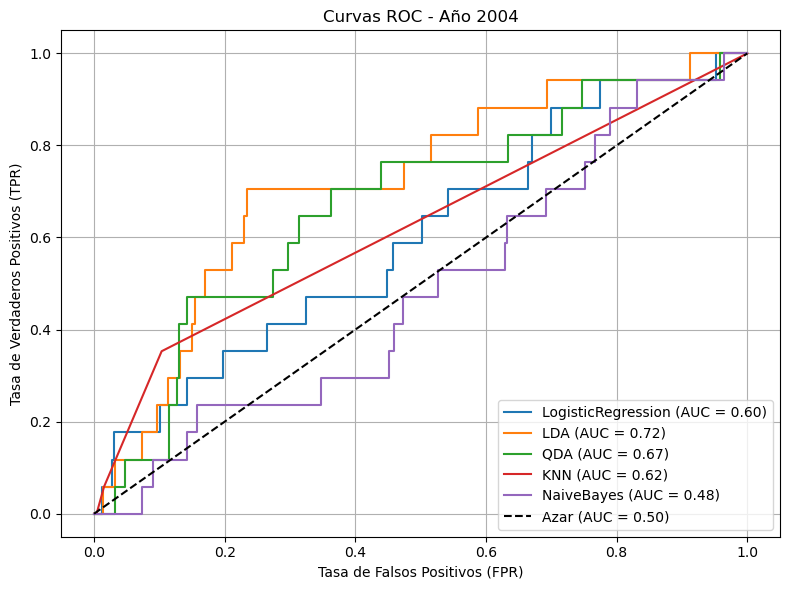

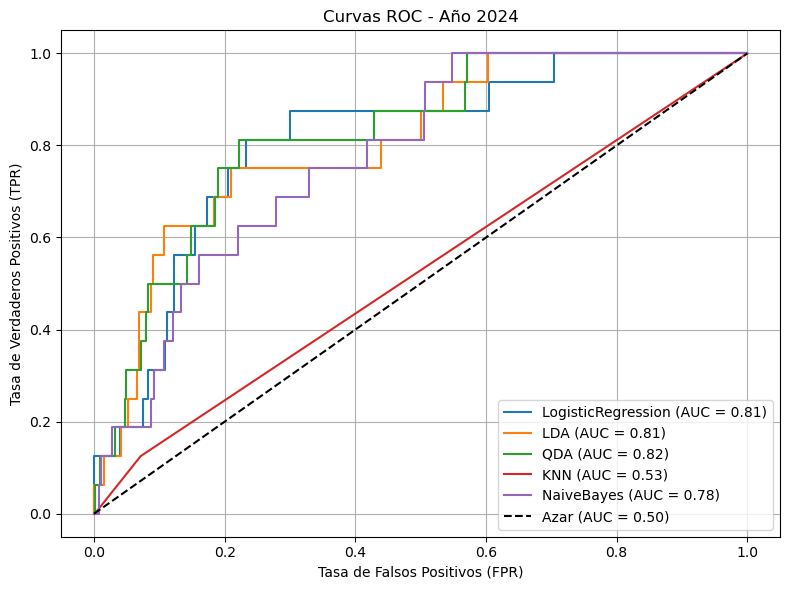

In [107]:
import matplotlib.pyplot as plt

# Graficar curvas ROC por año
for year in years:
    plt.figure(figsize=(8, 6))
    for model_name, metrics in results_fixed[year].items():
        fpr = metrics['fpr']
        tpr = metrics['tpr']
        auc_score = metrics['auc']
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label="Azar (AUC = 0.50)")
    plt.title(f"Curvas ROC - Año {int(year)}")
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/ROC_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()


# Punto 4

In [43]:
# Lista para tabla comparativa
comparison_rows = []

for year in years:
    for model_name, metrics in results_fixed[year].items():
        comparison_rows.append({
            "Año": year,
            "Modelo": model_name,
            "Accuracy": round(metrics['accuracy'], 4),
            "AUC": round(metrics['auc'], 4)
        })

# Convertir a DataFrame
comparison_df = pd.DataFrame(comparison_rows).sort_values(by=["Año", "Modelo"])

# Mostrar al usuario
display(comparison_df)

,Año,Modelo,Accuracy,AUC
3,2004,KNN,0.9647,0.6250
1,2004,LDA,0.9610,0.7181
0,2004,LogisticRegression,0.9685,0.5995
4,2004,NaiveBayes,0.9332,0.4839
2,2004,QDA,0.9295,0.6717
8,2024,KNN,0.9817,0.5268
6,2024,LDA,0.9817,0.8086
5,2024,LogisticRegression,0.9817,0.8102
9,2024,NaiveBayes,0.9817,0.7782
7,2024,QDA,0.9484,0.8232


# Punto 5

In [48]:
import numpy as np
import pandas as pd
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/base_dummies.dta")

# Filtrar personas que reportaron su condición de actividad
df = df[df['estado'].isin([0])]

# Guardar la base filtrada
df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/no_respondieron.dta", write_index=False)

In [52]:
import numpy as np
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/no_respondieron.dta")

# Paso 1: Reemplazar valores vacíos por NaN
df['ch14'] = df['ch14'].replace({'': np.nan})

# Paso 2: Convertir todos los valores a strings para manejarlos de forma uniforme
df['ch14'] = df['ch14'].astype(str).str.strip()

# Paso 3: Función para limpiar cada valor
def convertir_a_entero(valor):
    if valor in ['98', '99', '98.0', '99.0']:
        return int(float(valor))  # mantener 98 y 99 como enteros
    try:
        # Convertimos valores como '01', '2.0', etc., a enteros
        return int(float(valor))
    except:
        return 0  # Si no se puede convertir, ponemos NaN

# Paso 4: Aplicar la función a toda la columna
df['ch14'] = df['ch14'].apply(convertir_a_entero)

/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/2498704827.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ch14'] = df['ch14'].replace({'': np.nan})


In [54]:
df['ch12'] = pd.to_numeric(df['ch12'], errors='coerce')
df['ch13'] = pd.to_numeric(df['ch13'], errors='coerce')

In [58]:
import numpy as np
import pandas as pd

def calcular_anos_educacion(row):
    nivel = row['ch12']
    finalizo = row['ch13']
    ultimo_aprobado = row['ch14']

    if nivel == 9 or ultimo_aprobado in [98, 99]:
        return np.nan
    
    # Si finalizó el nivel
    if finalizo == 1:
        return {
            1: 0,
            2: 7,
            3: 9,
            4: 12,   # asumimos primaria + secundaria
            5: 12,
            6: 15,   # terciario
            7: 17,   # universitario
            8: 20,   # posgrado
        }.get(nivel, np.nan)

    # Si no lo finalizó
    if finalizo == 2:
        # Años previos al nivel actual
        previos = {
            1: 0,
            2: 0,
            3: 0,
            4: 9,
            5: 9,
            6: 12,
            7: 15,
            8: 17
        }.get(nivel, 0)

        # Validar que el año aprobado esté en rango
        if 1 <= ultimo_aprobado <= 9:
            return previos + ultimo_aprobado
        else:
            return np.nan

    return np.nan

# Asumiendo que tus datos están en un DataFrame llamado df:
df['anos_educacion'] = df.apply(calcular_anos_educacion, axis=1)

df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/no_respondieron_creamos_variable.dta", write_index=False)

In [101]:
import pandas as pd
import numpy as np

# Cargar base original
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/no_respondieron_creamos_variable.dta")

# Ajustar por inflación para 2004
ajuste_inflacion = 500
df.loc[df['ano4'] == 2004, 'p47t'] = df.loc[df['ano4'] == 2004, 'p47t'] * ajuste_inflacion

# Variables derivadas
df['edad_cuad'] = df['ch06'] ** 2
df['experiencia_pot'] = df['ch06'] - df['nivel_ed'] - 6
df['edad_x_exp'] = df['ch06'] * df['experiencia_pot']
df['log_ing'] = np.log1p(df['p47t'])  # evita log(0)
df['ingreso_sin_subsidio'] = df['p47t'] - df['t_vi']

# Verificación rápida
print(df[['ano4', 'p47t', 'log_ing']].head())
print(df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'ingreso_sin_subsidio']].head())

# Guardar base final
df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/no_responieron_tp3.dta", write_index=False)


     ano4  p47t  log_ing
0  2024.0   NaN      NaN
1  2024.0   NaN      NaN
2  2024.0   NaN      NaN
   edad_cuad  experiencia_pot  edad_x_exp  ingreso_sin_subsidio
0     4356.0             56.0      3696.0                   NaN
1     2809.0             43.0      2279.0                   NaN
2     1089.0             23.0       759.0                   NaN


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1170445689.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['edad_cuad'] = df['ch06'] ** 2
/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1170445689.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['experiencia_pot'] = df['ch06'] - df['nivel_ed'] - 6
/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/1170445689.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

In [105]:
# Cargar la base original completa con missing data en ingresos
df_no_respond = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/no_responieron_tp3.dta")
df_respond = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")

# Asegurarnos de que 'desocupado' esté disponible en la base respondieron
df_respond['desocupado'] = df_respond['estado'].apply(lambda x: 1 if x == 2 else 0)

# Features completos a imputar
features_full = ['edad_cuad', 'experiencia_pot', 'edad_x_exp',
                 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']

# Medias de las variables sobre base respondieron (solo año 2024)
mean_values = df_respond[df_respond['ano4'] == 2024][features_full].mean()

# Imputar valores faltantes en no_respond usando esas medias
df_no_respond_imp = df_no_respond.copy()
for col in features_full:
    df_no_respond_imp[col] = df_no_respond_imp[col].fillna(mean_values[col])

# Entrenar modelo logístico con datos de 2024
df_train = df_respond[df_respond['ano4'] == 2024].dropna(subset=features_full + ['desocupado'])
X_train = df_train[features_full]
y_train = df_train['desocupado']

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_train, y_train)

# Aplicar predicción sobre la base imputada
X_imputed = df_no_respond_imp[features_full]
y_pred_proba_imp = logit_model.predict_proba(X_imputed)[:, 1]
y_pred_imp = (y_pred_proba_imp >= 0.5).astype(int)

# Resultados
n_total_imp = len(X_imputed)
n_desocupados_imp = y_pred_imp.sum()
proporcion_imp = n_desocupados_imp / n_total_imp

{
    "Total personas con imputación": n_total_imp,
    "Clasificados como desocupados": n_desocupados_imp,
    "Proporción estimada": round(proporcion_imp, 4)
}


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_63992/2756581024.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_respond['desocupado'] = df_respond['estado'].apply(lambda x: 1 if x == 2 else 0)


{'Total personas con imputación': 3,
 'Clasificados como desocupados': 0,
 'Proporción estimada': 0.0}